### Authors

- Anna Beketova
- Shatu Ahmed

Target repository: [week3](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/tree/Embedding/week3)

# Labbook Week 3 - Embedding using Convolutional Layers with Sigmoid activation function

## Code

### Data Preprocessing

In [4]:
import pandas as pd
from Bio import SeqIO
import csv

#read data
data = pd.read_csv("mapmanreferencebins_simpl.tsv", sep="\t")

bincode_dict = {} # dictionary to store all identifiers of each family


for index, row in data.iterrows():
    bincode = row['BINCODE'].strip("'")
    protein_id = row['IDENTIFIER'].strip("'").lower()
    if(protein_id):
        if(bincode not in bincode_dict):
            bincode_dict[bincode] = []
        bincode_dict[bincode].append(protein_id)


print(sum(len(v) for v in bincode_dict.values()))

proteins = "protein.fa"
protein_dict = {}

for record in SeqIO.parse(proteins, "fasta"):
    uniprot_id = record.id.split("|")[-1].lower()
    sequence = str(record.seq)
    protein_dict[uniprot_id] = sequence

grouped_dict = {}
for bincode, protein_ids in bincode_dict.items():
    sequences = [protein_dict[p] for p in protein_ids if p in protein_dict]
    if sequences:
        grouped_dict[bincode] = sequences
    else:
        grouped_dict[bincode] = []

result = "labeled_sequences.csv"
with open(result, "w") as newfile:
    newfile.write("bincode,sequence\n")
    for bincode, sequences in grouped_dict.items():
        for seq in sequences:
            newfile.write(f"{bincode}, {seq}\n")


cleaned_rows = []

with open("labeled_sequences.csv", "r") as infile:
    reader = csv.reader(infile)
    for row in reader:
        if len(row) > 2:
            bincode = row[0]
            sequence = ''.join(row[1:]).replace('"', '').replace("'", "") # Merge falsely added columns and clean quotes
            cleaned_rows.append([bincode, sequence])
        elif len(row) == 2:
            cleaned_rows.append(row)
        else:
            print(f"Skipping malformed row: {row}")


with open("NEWHELP_labeled_sequences.csv", "w") as outfile:
    writer = csv.writer(outfile)
    writer.writerows(cleaned_rows)

print("done")

50425
done


### Embedding step


In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

labled = pd.read_csv("NEWHELP_labeled_sequences.csv")

# Kidera factors (without processing of not-aminoacid characters)
kidera_factors = {
    'A': [-1.56, -1.67, -0.97, -0.27, -0.93, -0.78, -0.2, -0.08, 0.21, -0.48],
    'C': [0.12, -0.89, 0.45, -1.05, -0.71, 2.41, 1.52, -0.69, 1.13, 1.1],
    'D': [0.58, -0.22, -1.58, 0.81, -0.92, 0.15, -1.52, 0.47, 0.76, 0.7],
    'E': [-1.45, 0.19, -1.61, 1.17, -1.31, 0.4, 0.04, 0.38, -0.35, -0.12],
    'F': [-0.21, 0.98, -0.36, -1.43, 0.22, -0.81, 0.67, 1.1, 1.71, -0.44],
    'G': [1.46, -1.96, -0.23, -0.16, 0.1, -0.11, 1.32, 2.36, -1.66, 0.46],
    'H': [-0.41, 0.52, -0.28, 0.28, 1.61, 1.01, -1.85, 0.47, 1.13, 1.63],
    'I': [-0.73, -0.16, 1.79, -0.77, -0.54, 0.03, -0.83, 0.51, 0.66, -1.78],
    'K': [-0.34, 0.82, -0.23, 1.7, 1.54, -1.62, 1.15, -0.08, -0.48, 0.6],
    'L': [-1.04, 0, -0.24, -1.1, -0.55, -2.05, 0.96, -0.76, 0.45, 0.93],
    'M': [-1.4, 0.18, -0.42, -0.73, 2, 1.52, 0.26, 1.23, -1.27, 0.27],
    'N': [1.14, -0.07, -0.12, 0.81, 0.18, 0.37, -0.09, -2.3, 1.1, -1.73],
    'P': [2.06, 0.24, -1.15, -0.75, 0.88, -0.45, 0.84, -0.71, 0.74, -0.28],
    'Q': [-0.47, 1.27, 0.07, 1.1, 1.1, 0.59, 0.92, -1.15, -0.03, -2.33],
    'R': [0.22, -0.7, 1.37, 1.87, -1.7, 0.46, 0.84, -0.39, 0.23, 0.93],
    'S': [0.81, 1.27, 0.16, 0.42, -0.21, -0.43, 0.92, -1.15, -0.97, -0.23],
    'T': [0.26, -1.08, 1.21, 0.63, -0.1, 0.21, 0.24, -1.15, -0.56, 0.19],
    'V': [-0.74, -0.7, 2.04, -0.4, 0.5, -0.81, -1.07, 0.06, -2.3, -0.6],
    'W': [0.3, -0.71, -0.72, -1.57, -1.16, 0.57, -0.48, -0.4, -0.05, 0.53],
    'Y': [1.38, 2.1, 0.8, -0.56, 0, -0.68, -0.31, 1.03, -0.6, 0.53]
}

default_kidera_vector = [0.0] * 10  # Default vector (unknown letters are set to 0)

def compute_kidera_embedding(sequence, kidera_factors, default_kidera_vector):

    return np.array([kidera_factors.get(aa, default_kidera_vector) for aa in sequence])

def process_sequences(sequences, max_length, kidera_dict, default_vector):

    kidera_matrices = [compute_kidera_embedding(seq, kidera_dict, default_vector) for seq in sequences]
    return pad_sequences(kidera_matrices, maxlen=max_length, padding='post', dtype='float32')

sequences = labled['sequence'].tolist()

# Process the sequences and pad them
max_length = 409  # will be adjusted in the future to 750 

kidera_encoded_sequences = process_sequences(sequences, max_length, kidera_factors, default_kidera_vector)

#Display processed sequences
#print(kidera_encoded_sequences[:2])
#print(labled.head())



2024-12-16 19:35:56.737581: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-16 19:35:56.779024: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-16 19:35:56.779070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-16 19:35:56.780516: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-16 19:35:56.787194: I tensorflow/core/platform/cpu_feature_guar

### Labeling

Multi-label classification:

In [13]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

data = pd.read_csv('NEWHELP_labeled_sequences.csv')
# Convert 'bincode' into lists of labels
data['bincode'] = data['bincode'].str.split(', ')
mlb = MultiLabelBinarizer()
bincode_encoded = mlb.fit_transform(data['bincode'])  # Multi-hot encoding
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)

print(len(bincode_encoded))

# test output array
#print(bincode_encoded[400:420])

#print("Number of positive labels per class:", bincode_encoded.sum(axis=0))
#print("Number of positive labels per sample:", bincode_encoded.sum(axis=1))



50425
Number of Positive Labels per Class: [64  4  1 ...  7  5 19]
Number of Positive Labels per Sample: [1 1 1 ... 1 1 1]


### Implementing a multi layered Convolutional Model


Epoch 1/20 - Train Loss: 0.0164, Val Loss: 0.0203
Epoch 2/20 - Train Loss: 0.0402, Val Loss: 0.0404
Epoch 3/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 4/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 5/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 6/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 7/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 8/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 9/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 10/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 11/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 12/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 13/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 14/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 15/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 16/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 17/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 18/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 19/20 - Train Loss: 0.0403, Val Loss: 0.0404
Epoch 20/20 - Train Loss: 0.0403, Val Lo

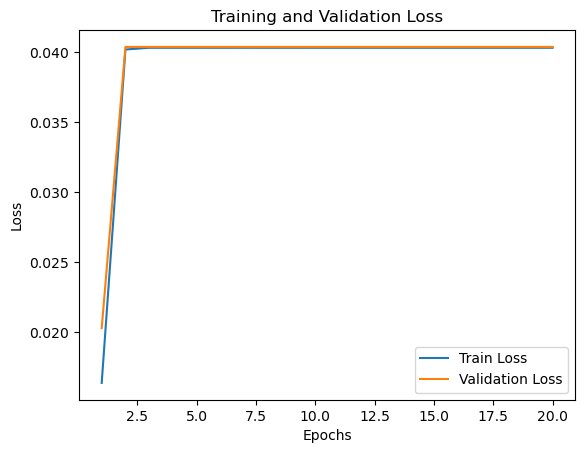

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)  # labels are converted to float for BCE loss

# Permute the tensor to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)

# Data split
dataset = TensorDataset(kidera_encoded_sequences_tensor, labels_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)  # Random seed for reproducibility
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders for batching
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

num_classes = labels_tensor.shape[1]

# CNN Model defined
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self._calculate_conv_output_size()
        self.fc = nn.Linear(self.conv_output_size, num_classes)
        self.sigmoid = nn.Sigmoid()  # sigmoid activation 

    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 409)  # Simulate a single input
        dummy_output = self.conv1(dummy_input)
        dummy_output = self.conv2(dummy_output)
        dummy_output = self.conv3(dummy_output)
        dummy_output = self.conv4(dummy_output)
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

# Model, loss function, and optimizer initialisation
model = ConvolutionalNetwork()
loss_fn = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    for batch in train_loader:
        batch_data, batch_labels = batch
        optimizer.zero_grad() 
        outputs = model(batch_data)
        loss = loss_fn(outputs, batch_labels)  # Compute loss
        loss.backward() 
        optimizer.step()
        total_train_loss += loss.item()

    # Evaluate on validation set
    model.eval()  
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item()

    # Average losses
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


y_test = []
y_pred = []

model.eval()  
with torch.no_grad():
    for batch in val_loader:
        batch_data, batch_labels = batch
        outputs = model(batch_data)
        predictions = (outputs > 0.5).float()  # threshold to convert probabilities to binary
        y_test.extend(batch_labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

y_test = np.array(y_test)
y_pred = np.array(y_pred)

# shapes of the predictions and true labels
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

# Number of classes
print("Number of classes:", num_classes)

# Metrics
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


# MCC for multi-label classification is an average of MCCs of each class
mcc_scores = []

# Compute MCC for each class
for i in range(y_test.shape[1]):
    true_labels = y_test[:, i]
    pred_labels = y_pred[:, i]
    
    # Check if the class has at least two unique values (both 0 and 1)
    if len(np.unique(true_labels)) > 1 and len(np.unique(pred_labels)) > 1:
        mcc = matthews_corrcoef(true_labels, pred_labels)
        mcc_scores.append(mcc)
    else:
        mcc_scores.append(np.nan)  # Append NaN for classes with no variation

# Filter out NaN values when calculating the average
filtered_mcc_scores = [score for score in mcc_scores if not np.isnan(score)]

# Average MCC
if len(filtered_mcc_scores) > 0:
    average_mcc = np.mean(filtered_mcc_scores)
    print(f"Average Matthews Correlation Coefficient: {average_mcc:.4f}")
else:
    print("No valid classes found for MCC calculation.")


plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


## Experiment history

12.12.24 changes:
<ul>
    <li> The data is random split -> seed for reproducibility 42 is set 
    <li> Multi-class labeling
    <li> Cross entropy loss function, Sigmoid output layer
    <li> Result: Training and validation loss are very large and don't change
</ul>

13.12.24 changes:
<ul>
    <li> Multi label instead of multi class
    <li> BCEWithLogitsLoss()
    <li> batch_labels = batch_labels.float()
    <li> Result: model does not train at all
</ul>
<ul>
    <li> Adjusted learning rate to 0.0001
    <li> Added pooling layers 
    <li> Result: model does not train
</ul>

<ul>
    <li> Adjusted learning rate to 0.01
    <li> Result: model does not train
</ul>

14.12.24 changes:
<ul> 
    <li> Number of convolutional layers reduced to 2
    <li> Removed pooling
    <li> Result: model does not train
</ul>

15.12.24 changes:
<ul> 
    <li> 4 convolutional layers
    <li> Learning rate 0.001
    <li> BCELoss()
    <li> Result: training loss increases, after 3rd epoch does not change (see report_week3.md, first graph)
</ul>

<ul> 
    <li> BCEWithLogitsLoss() instead of BCELoss()
    <li> Result: almost same result, training loss does not change
</ul>

16.12.24 changes:
<ul>
    <li> 30 epochs, attempts to calculate MCC as average value of every MCC of each class
    <li> Result: MCC: NaN; same tendency of training loss
</ul>

<ul> 
    <li> prediction threshold is set to 0.2 from 0.5
    <li> NaN MCC values were filtered 
    <li> Result: MCC negative, other metrics are 0, same tendency of training loss (see report_week3.md, second graph)
</ul>
    
<ul>
    <li> softmax function instead of sigmoid
    <li> Result: incompatible with the model architecture; the idea was abandoned 